In [3]:
from google.colab import drive
import os
import pandas as pd

# Montar Google Drive
drive.mount('/content/drive')

# Definir rutas
ruta_proyecto = '/content/drive/MyDrive/Proyecto_Amazon_Reviews'
ruta_archivo = os.path.join(ruta_proyecto, 'muestra_amazon_original.csv')

# Cargar la muestra perfecta
df_muestra = pd.read_csv(ruta_archivo)
print("Dataset cargado y listo para el preprocesamiento de texto.")

Mounted at /content/drive
Dataset cargado y listo para el preprocesamiento de texto.


Bloque 1. Exploración inicial del dataset

In [4]:
# Ver primeras filas
print("Primeras 5 filas:")
display(df_muestra.head())

# Revisar dimensiones
filas, columnas = df_muestra.shape

print("\nDimensiones del dataset:")
print(f"Filas: {filas}")
print(f"Columnas: {columnas}")

# Revisar columnas
print("\nColumnas disponibles:")
print(df_muestra.columns.tolist())

# Revisar tipos de datos
print("\nTipos de datos:")
print(df_muestra.dtypes)

# Revisar valores nulos
print("\nValores nulos por columna:")
print(df_muestra.isnull().sum())

# Revisar distribución de clases
print("\nDistribución de clases:")
print(df_muestra["etiqueta"].value_counts().sort_index())

# Revisar proporción de clases
print("\nPorcentaje por clase:")
print(
    round(
        df_muestra["etiqueta"].value_counts(normalize=True).sort_index() * 100,
        2
    )
)

Primeras 5 filas:


,etiqueta,titulo,contenido
0,2,Dangerously In Love More Like Dangerous In Skills,"Beyonce Giselle Knowles, showcased her writing..."
1,1,"Bringing politics into a children's story? No,...","Brainwashing kids that ""big oil is evil"" is ju..."
2,2,Remarkable work,Exceptional work on the nature of resistance t...
3,1,"Great for the first year, now need to replace",This toaster oven was great for the first year...
4,1,not worth the time and the money,"Attracted by the title, I thought it could be ..."



Dimensiones del dataset:
Filas: 15000
Columnas: 3

Columnas disponibles:
['etiqueta', 'titulo', 'contenido']

Tipos de datos:
etiqueta      int64
titulo       object
contenido    object
dtype: object

Valores nulos por columna:
etiqueta     0
titulo       0
contenido    0
dtype: int64

Distribución de clases:
etiqueta
1    7500
2    7500
Name: count, dtype: int64

Porcentaje por clase:
etiqueta
1    50.0
2    50.0
Name: proportion, dtype: float64


Bloque 2. Guardar evidencia

In [5]:
# Crear resumen del dataset
resumen_dataset = pd.DataFrame({
    "Metrica": [
        "Numero de filas",
        "Numero de columnas",
        "Clase negativa (1)",
        "Clase positiva (2)"
    ],
    "Valor": [
        len(df_muestra),
        len(df_muestra.columns),
        (df_muestra["etiqueta"] == 1).sum(),
        (df_muestra["etiqueta"] == 2).sum()
    ]
})

print("Resumen del dataset:")
display(resumen_dataset)

Resumen del dataset:


,Metrica,Valor
0,Numero de filas,15000
1,Numero de columnas,3
2,Clase negativa (1),7500
3,Clase positiva (2),7500


Bloque 3. Guardar evidencia en Drive

In [6]:
# Definir ruta
ruta_resumen = os.path.join(
    ruta_proyecto,
    "resumen_exploracion.csv"
)

# Guardar resumen
resumen_dataset.to_csv(
    ruta_resumen,
    index=False
)

print("Resumen guardado correctamente.")

Resumen guardado correctamente.


In [7]:
df_muestra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   etiqueta   15000 non-null  int64 
 1   titulo     15000 non-null  object
 2   contenido  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


Fase 2. Construcción de la reseña

In [8]:
# Bloque 1. Crear la reseña completa
# Unir titulo y contenido
df_muestra["resena"] = (
    df_muestra["titulo"].astype(str)
    + " "
    + df_muestra["contenido"].astype(str)
)

print("Columna 'resena' creada correctamente.")

# Bloque 2. Verificar resultado
# Mostrar ejemplos
print("Ejemplo de reseña completa:\n")

for i in range(3):
    print(f"Reseña {i+1}:")
    print(df_muestra.loc[i, "resena"])
    print("-" * 80)

# Bloque 3. Conservar únicamente las variables necesarias
# Seleccionar columnas necesarias
df_resenas = df_muestra[["etiqueta", "resena"]].copy()

print("Nuevo dataframe creado.")
display(df_resenas.head())

# Bloque 4. Revisar longitud de las reseñas
# Calcular longitud
df_resenas["longitud"] = df_resenas["resena"].str.len()

print("Estadísticas de longitud:")
display(df_resenas["longitud"].describe())

# Bloque 5. Eliminar columna auxiliar
# Eliminar columna auxiliar
df_resenas.drop(columns=["longitud"], inplace=True)

# Bloque 6. Verificar estructura final
print(df_resenas.info())

display(df_resenas.head())

Columna 'resena' creada correctamente.
Ejemplo de reseña completa:

Reseña 1:
Dangerously In Love More Like Dangerous In Skills Beyonce Giselle Knowles, showcased her writing skills, her vocals, parts that she has not shown the world. This CD is worth 10 stars. It is on the same level as Aaliyah's Aaliyah CD. Her collaborations are perfect. Missy Elliot did a good song, Signs. And the Luther duet, Closer I Get To You, was sung much better by these two than Donnie And Roberta. Her ballads, and her uptempo songs balance out with giving u enough of both. Speechless, to me that is the best song on the album, its sexy and it is just the .... All in All, this is a CD for 03 & 04. U did ur thang Beyonce. Im so happy 4 u. U representin Texas. Bee~
--------------------------------------------------------------------------------
Reseña 2:
Bringing politics into a children's story? No, thanks! Brainwashing kids that "big oil is evil" is just wrong. The graphics was top-notch, as usual. I am NOT b

,etiqueta,resena
0,2,Dangerously In Love More Like Dangerous In Ski...
1,1,"Bringing politics into a children's story? No,..."
2,2,Remarkable work Exceptional work on the nature...
3,1,"Great for the first year, now need to replace ..."
4,1,not worth the time and the money Attracted by ...


Estadísticas de longitud:


,longitud
count,15000.000000
mean,431.460133
std,237.363891
min,100.000000
25%,232.000000
50%,383.000000
75%,592.000000
max,1014.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   etiqueta  15000 non-null  int64 
 1   resena    15000 non-null  object
dtypes: int64(1), object(1)
memory usage: 234.5+ KB
None


,etiqueta,resena
0,2,Dangerously In Love More Like Dangerous In Ski...
1,1,"Bringing politics into a children's story? No,..."
2,2,Remarkable work Exceptional work on the nature...
3,1,"Great for the first year, now need to replace ..."
4,1,not worth the time and the money Attracted by ...


Fase 3. Limpieza de texto

In [9]:
# Subbloque 3.1 Importar librerías

# Importar librerías
import re
import string
import nltk

# Descargar stopwords
nltk.download("stopwords")

from nltk.corpus import stopwords

# Subbloque 3.2 Crear lista de stopwords
# Cargar stopwords en inglés
palabras_vacias = set(stopwords.words("english"))

print(f"Cantidad de stopwords: {len(palabras_vacias)}")

# Subbloque 3.3 Mostrar ejemplo original
# Mostrar ejemplo original
print("Texto original:\n")
print(df_resenas.loc[0, "resena"])

# Subbloque 3.4 Crear función de limpieza
# Limpiar texto
def limpiar_resena(texto):

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar puntuación
    texto = texto.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Eliminar caracteres especiales y números
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)

    # Separar palabras
    palabras = texto.split()

    # Eliminar stopwords
    palabras = [
        palabra
        for palabra in palabras
        if palabra not in palabras_vacias
    ]

    # Unir palabras
    texto = " ".join(palabras)

    return texto

# Subbloque 3.5 Aplicar limpieza
# Crear columna limpia
df_resenas["resena_limpia"] = (
    df_resenas["resena"]
    .apply(limpiar_resena)
)

print("Columna 'resena_limpia' creada correctamente.")

# Subbloque 3.6 Comparar antes y después
# Mostrar comparación
print("RESEÑA ORIGINAL\n")
print(df_resenas.loc[0, "resena"])

print("\n" + "="*100 + "\n")

print("RESEÑA LIMPIA\n")
print(df_resenas.loc[0, "resena_limpia"])

# Subbloque 3.7 Revisar valores nulos
# Revisar nulos
print("Valores nulos:")

print(
    df_resenas[
        ["etiqueta", "resena_limpia"]
    ].isnull().sum()
)

# Subbloque 3.8 Crear dataset final
# Aquí dejamos únicamente las columnas que usará TF-IDF.
# Crear dataset final
df_limpio = df_resenas[
    ["etiqueta", "resena_limpia"]
].copy()

display(df_limpio.head())

# Subbloque 3.9 Revisar estructura final
# Revisar estructura
print(df_limpio.info())

# Subbloque 3.10 Guardar dataset limpio
# Definir ruta
ruta_limpio = os.path.join(
    ruta_proyecto,
    "dataset_limpio.csv"
)

# Guardar dataset
df_limpio.to_csv(
    ruta_limpio,
    index=False
)

print("Dataset limpio guardado.")

# Subbloque 3.11 Guardar evidencia
# Mostrar tamaño final
print("Dimensiones del dataset limpio:")
print(df_limpio.shape)

print("\nDistribución de clases:")
print(
    df_limpio["etiqueta"]
    .value_counts()
    .sort_index()
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Cantidad de stopwords: 198
Texto original:

Dangerously In Love More Like Dangerous In Skills Beyonce Giselle Knowles, showcased her writing skills, her vocals, parts that she has not shown the world. This CD is worth 10 stars. It is on the same level as Aaliyah's Aaliyah CD. Her collaborations are perfect. Missy Elliot did a good song, Signs. And the Luther duet, Closer I Get To You, was sung much better by these two than Donnie And Roberta. Her ballads, and her uptempo songs balance out with giving u enough of both. Speechless, to me that is the best song on the album, its sexy and it is just the .... All in All, this is a CD for 03 & 04. U did ur thang Beyonce. Im so happy 4 u. U representin Texas. Bee~
Columna 'resena_limpia' creada correctamente.
RESEÑA ORIGINAL

Dangerously In Love More Like Dangerous In Skills Beyonce Giselle Knowles, showcased her writing skills, her vocals, parts that she has not shown the world. This CD is worth 10 stars. It is on the same level as Aaliyah's 

,etiqueta,resena_limpia
0,2,dangerously love like dangerous skills beyonce...
1,1,bringing politics childrens story thanks brain...
2,2,remarkable work exceptional work nature resist...
3,1,great first year need replace toaster oven gre...
4,1,worth time money attracted title thought could...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   etiqueta       15000 non-null  int64 
 1   resena_limpia  15000 non-null  object
dtypes: int64(1), object(1)
memory usage: 234.5+ KB
None
Dataset limpio guardado.
Dimensiones del dataset limpio:
(15000, 2)

Distribución de clases:
etiqueta
1    7500
2    7500
Name: count, dtype: int64


Fase 5. División entrenamiento-prueba

In [10]:
# Importar función
from sklearn.model_selection import train_test_split

# Definir variables
X = df_limpio["resena_limpia"]

y = df_limpio["etiqueta"]

# Dividir datos
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Mostrar tamaños
print("Entrenamiento:")
print(X_entrenamiento.shape[0])

print("\nPrueba:")
print(X_prueba.shape[0])


# Verificar balance
print("Clases en entrenamiento:")
print(
    y_entrenamiento.value_counts().sort_index()
)

print("\nClases en prueba:")
print(
    y_prueba.value_counts().sort_index()
)


# Guardar conjuntos (opcional)
# Crear dataframes
entrenamiento = pd.DataFrame({
    "etiqueta": y_entrenamiento,
    "resena_limpia": X_entrenamiento
})

prueba = pd.DataFrame({
    "etiqueta": y_prueba,
    "resena_limpia": X_prueba
})

# Guardar archivos
entrenamiento.to_csv(
    os.path.join(
        ruta_proyecto,
        "datos_entrenamiento.csv"
    ),
    index=False
)

prueba.to_csv(
    os.path.join(
        ruta_proyecto,
        "datos_prueba.csv"
    ),
    index=False
)

print("Conjuntos guardados.")

Entrenamiento:
12000

Prueba:
3000
Clases en entrenamiento:
etiqueta
1    6000
2    6000
Name: count, dtype: int64

Clases en prueba:
etiqueta
1    1500
2    1500
Name: count, dtype: int64
Conjuntos guardados.


Fase 6. Vectorización TF-IDF

Objetivo

Convertir las reseñas limpias en vectores numéricos para que los modelos de clasificación puedan procesarlas.

In [11]:
# Subbloque 6.1 Importar librerías
# Importar librerías
from sklearn.feature_extraction.text import TfidfVectorizer

import pickle

# Subbloque 6.2 Crear vectorizador
# Para este proyecto académico:
# unigramas y bigramas
# eliminar términos extremadamente raros
#limitar vocabulario

# Crear vectorizador
vectorizador_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5
)

print("Vectorizador creado.")

# Subbloque 6.3 Ajustar con entrenamiento
# Ajustar vectorizador
X_entrenamiento_tfidf = vectorizador_tfidf.fit_transform(
    X_entrenamiento
)

print("Vectorización de entrenamiento completada.")

# Subbloque 6.4 Transformar prueba
# Transformar prueba
X_prueba_tfidf = vectorizador_tfidf.transform(
    X_prueba
)

print("Vectorización de prueba completada.")

# Subbloque 6.5 Revisar dimensiones
# Mostrar dimensiones
print("Matriz entrenamiento:")
print(X_entrenamiento_tfidf.shape)

print("\nMatriz prueba:")
print(X_prueba_tfidf.shape)

# Subbloque 6.6 Revisar tamaño del vocabulario
# Mostrar vocabulario
cantidad_terminos = len(
    vectorizador_tfidf.get_feature_names_out()
)

print("Cantidad de términos:")
print(cantidad_terminos)

# Subbloque 6.7 Mostrar algunos términos
# Mostrar términos
terminos = vectorizador_tfidf.get_feature_names_out()

print("Primeros 20 términos:")
print(terminos[:20])

# Subbloque 6.8 Guardar vectorizador
# Definir ruta
ruta_vectorizador = os.path.join(
    ruta_proyecto,
    "vectorizador_tfidf.pkl"
)

# Guardar vectorizador
with open(ruta_vectorizador, "wb") as archivo:
    pickle.dump(
        vectorizador_tfidf,
        archivo
    )

print("Vectorizador guardado.")

# Subbloque 6.9 Verificar archivo guardado
# Verificar archivo
print(
    os.path.exists(ruta_vectorizador)
)

Vectorizador creado.
Vectorización de entrenamiento completada.
Vectorización de prueba completada.
Matriz entrenamiento:
(12000, 10000)

Matriz prueba:
(3000, 10000)
Cantidad de términos:
10000
Primeros 20 términos:
['aa' 'aaa' 'abandoned' 'abbey' 'abc' 'abilities' 'ability' 'able'
 'able find' 'able get' 'able put' 'able read' 'able see' 'able take'
 'able use' 'abound' 'abs' 'absolute' 'absolutely' 'absolutely love']
Vectorizador guardado.
True


Fase 7. Modelo Naive Bayes
Objetivo
Construir un modelo base para comparar posteriormente contra SVM.

In [12]:
# Subbloque 7.1 Importar librerías
# Importar librerías
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pickle

# Subbloque 7.2 Crear modelo
# Crear modelo
modelo_naive_bayes = MultinomialNB()

print("Modelo creado.")

# Subbloque 7.3 Entrenar modelo
# Entrenar modelo
modelo_naive_bayes.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

print("Entrenamiento completado.")

# Subbloque 7.4 Realizar predicciones
# Generar predicciones
predicciones_nb = modelo_naive_bayes.predict(
    X_prueba_tfidf
)

print("Predicciones completadas.")

# Subbloque 7.5 Calcular métricas
# Calcular métricas
accuracy_nb = accuracy_score(
    y_prueba,
    predicciones_nb
)

precision_nb = precision_score(
    y_prueba,
    predicciones_nb,
    average="weighted"
)

recall_nb = recall_score(
    y_prueba,
    predicciones_nb,
    average="weighted"
)

f1_nb = f1_score(
    y_prueba,
    predicciones_nb,
    average="weighted"
)

# Subbloque 7.6 Mostrar resultados
# Mostrar métricas
print("Resultados Naive Bayes\n")

print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

# Subbloque 7.7 Reporte de clasificación
# Mostrar reporte
print(
    classification_report(
        y_prueba,
        predicciones_nb
    )
)

# Subbloque 7.8 Revisar algunas predicciones
# Mostrar ejemplos
for i in range(5):

    print(f"\nEjemplo {i+1}")

    print(
        "Etiqueta real:",
        y_prueba.iloc[i]
    )

    print(
        "Predicción:",
        predicciones_nb[i]
    )

    print("-" * 50)

# Subbloque 7.9 Guardar modelo
# Definir ruta
ruta_naive_bayes = os.path.join(
    ruta_proyecto,
    "modelo_naive_bayes.pkl"
)

# Guardar modelo
with open(ruta_naive_bayes, "wb") as archivo:

    pickle.dump(
        modelo_naive_bayes,
        archivo
    )

print("Modelo guardado.")

# Subbloque 7.10 Verificar archivo
# Verificar archivo
print(
    os.path.exists(
        ruta_naive_bayes
    )
)

Modelo creado.
Entrenamiento completado.
Predicciones completadas.
Resultados Naive Bayes

Accuracy : 0.8493
Precision: 0.8493
Recall   : 0.8493
F1-Score : 0.8493
              precision    recall  f1-score   support

           1       0.85      0.85      0.85      1500
           2       0.85      0.85      0.85      1500

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000


Ejemplo 1
Etiqueta real: 1
Predicción: 1
--------------------------------------------------

Ejemplo 2
Etiqueta real: 2
Predicción: 2
--------------------------------------------------

Ejemplo 3
Etiqueta real: 1
Predicción: 1
--------------------------------------------------

Ejemplo 4
Etiqueta real: 2
Predicción: 2
--------------------------------------------------

Ejemplo 5
Etiqueta real: 1
Predicción: 1
--------------------------------------------------
Modelo guardado.
True


Fase 8. Modelo SVM
Objetivo

Entrenar un clasificador SVM utilizando las características TF-IDF.

In [13]:
# Subbloque 8.1 Importar librerías
# Importar librerías
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import pickle

# Subbloque 8.2 Crear modelo
# Crear modelo
modelo_svm = LinearSVC(
    random_state=42
)

print("Modelo creado.")

# Subbloque 8.3 Entrenar modelo
# Entrenar modelo
modelo_svm.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

print("Entrenamiento completado.")

# Subbloque 8.4 Realizar predicciones
# Generar predicciones
predicciones_svm = modelo_svm.predict(
    X_prueba_tfidf
)

print("Predicciones completadas.")

# Subbloque 8.5 Calcular métricas
# Calcular métricas
accuracy_svm = accuracy_score(
    y_prueba,
    predicciones_svm
)

precision_svm = precision_score(
    y_prueba,
    predicciones_svm,
    average="weighted"
)

recall_svm = recall_score(
    y_prueba,
    predicciones_svm,
    average="weighted"
)

f1_svm = f1_score(
    y_prueba,
    predicciones_svm,
    average="weighted"
)

# Subbloque 8.6 Mostrar resultados
# Mostrar métricas
print("Resultados SVM\n")

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

# Subbloque 8.7 Reporte de clasificación
# Mostrar reporte
print(
    classification_report(
        y_prueba,
        predicciones_svm
    )
)

# Subbloque 8.8 Revisar algunas predicciones
# Mostrar ejemplos
for i in range(5):

    print(f"\nEjemplo {i+1}")

    print(
        "Etiqueta real:",
        y_prueba.iloc[i]
    )

    print(
        "Predicción:",
        predicciones_svm[i]
    )

    print("-" * 50)

# Subbloque 8.9 Guardar modelo
# Definir ruta
ruta_svm = os.path.join(
    ruta_proyecto,
    "modelo_svm.pkl"
)

# Guardar modelo
with open(ruta_svm, "wb") as archivo:

    pickle.dump(
        modelo_svm,
        archivo
    )

print("Modelo guardado.")

# Subbloque 8.10 Verificar archivo
# Verificar archivo
print(
    os.path.exists(
        ruta_svm
    )
)

Modelo creado.
Entrenamiento completado.
Predicciones completadas.
Resultados SVM

Accuracy : 0.8540
Precision: 0.8540
Recall   : 0.8540
F1-Score : 0.8540
              precision    recall  f1-score   support

           1       0.85      0.85      0.85      1500
           2       0.85      0.86      0.85      1500

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000


Ejemplo 1
Etiqueta real: 1
Predicción: 2
--------------------------------------------------

Ejemplo 2
Etiqueta real: 2
Predicción: 2
--------------------------------------------------

Ejemplo 3
Etiqueta real: 1
Predicción: 1
--------------------------------------------------

Ejemplo 4
Etiqueta real: 2
Predicción: 1
--------------------------------------------------

Ejemplo 5
Etiqueta real: 1
Predicción: 1
--------------------------------------------------
Modelo guardado.
True


Fase 9. Evaluación y comparación

In [14]:
# Subbloque 9.1 Crear tabla de métricas
# Crear tabla comparativa
tabla_metricas = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_svm
    ],
    "Precision": [
        precision_nb,
        precision_svm
    ],
    "Recall": [
        recall_nb,
        recall_svm
    ],
    "F1_Score": [
        f1_nb,
        f1_svm
    ]
})

# Redondear valores
tabla_metricas = tabla_metricas.round(4)

display(tabla_metricas)

# Subbloque 9.2 Identificar mejor modelo
# Seleccionar mejor modelo
mejor_modelo = tabla_metricas.loc[
    tabla_metricas["F1_Score"].idxmax(),
    "Modelo"
]

print("Mejor modelo:")
print(mejor_modelo)

# Subbloque 9.3 Mostrar resumen
# Mostrar resumen
print("Resumen de resultados\n")

for _, fila in tabla_metricas.iterrows():

    print(f"Modelo: {fila['Modelo']}")
    print(f"Accuracy : {fila['Accuracy']}")
    print(f"Precision: {fila['Precision']}")
    print(f"Recall   : {fila['Recall']}")
    print(f"F1-Score : {fila['F1_Score']}")
    print("-" * 40)

# Subbloque 9.4 Guardar tabla comparativa
# quinto entregable
# Definir ruta
ruta_metricas = os.path.join(
    ruta_proyecto,
    "metricas_modelos.csv"
)

# Guardar tabla
tabla_metricas.to_csv(
    ruta_metricas,
    index=False
)

print("Tabla de métricas guardada.")

# Subbloque 9.5 Verificar archivo
# Verificar archivo
print(
    os.path.exists(
        ruta_metricas
    )
)

,Modelo,Accuracy,Precision,Recall,F1_Score
0,Naive Bayes,0.8493,0.8493,0.8493,0.8493
1,SVM,0.8540,0.8540,0.8540,0.8540


Mejor modelo:
SVM
Resumen de resultados

Modelo: Naive Bayes
Accuracy : 0.8493
Precision: 0.8493
Recall   : 0.8493
F1-Score : 0.8493
----------------------------------------
Modelo: SVM
Accuracy : 0.854
Precision: 0.854
Recall   : 0.854
F1-Score : 0.854
----------------------------------------
Tabla de métricas guardada.
True


1. Matriz de confusión

[[1275  225]
 [ 227 1273]]
[[1279  221]
 [ 217 1283]]


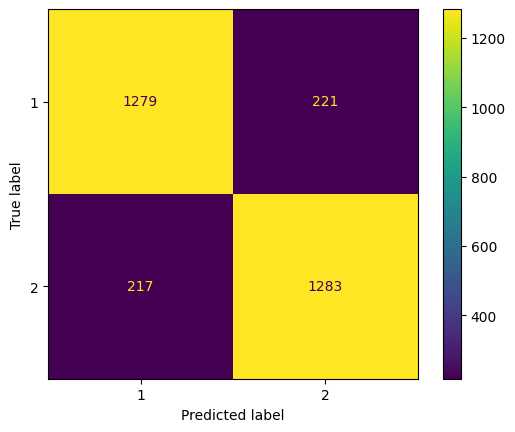

In [15]:
# Naive Bayes
from sklearn.metrics import confusion_matrix

matriz_nb = confusion_matrix(
    y_prueba,
    predicciones_nb
)

print(matriz_nb)

# SVM
matriz_svm = confusion_matrix(
    y_prueba,
    predicciones_svm
)

print(matriz_svm)

# version visual
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    predicciones_svm
)

plt.show()

2. Curva ROC

Naive Bayes

Sí puede generar probabilidades:
Por tanto sí puede generar ROC y AUC.

LinearSVC

No tiene predict_proba().

Pero sí tiene:
decision_function()
que sirve para ROC.

In [16]:
# Naive Bayes
probabilidades_nb = modelo_naive_bayes.predict_proba(
    X_prueba_tfidf
)

# LinearSVC
puntajes_svm = modelo_svm.decision_function(
    X_prueba_tfidf
)

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

BLOQUE 1. Búsqueda automática de hiperparámetros

Este bloque prueba varios valores para:

Naive Bayes (alpha)
SVM (C)

y genera tablas y gráficas.

RESULTADOS NAIVE BAYES


,Alpha,Accuracy,F1
0,0.01,0.840000,0.839999
1,0.10,0.843667,0.843666
2,0.50,0.847333,0.847331
3,1.00,0.849333,0.849333
4,2.00,0.846667,0.846664
5,5.00,0.844667,0.844657


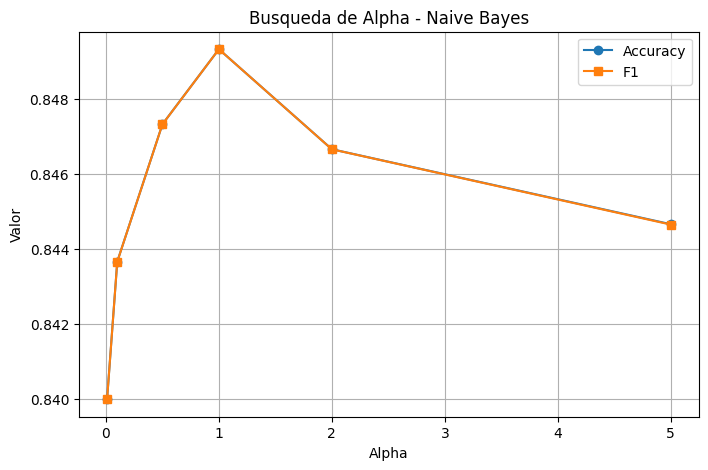

RESULTADOS SVM


,C,Accuracy,F1
0,0.01,0.839333,0.839333
1,0.10,0.864000,0.863999
2,1.00,0.854000,0.854000
3,5.00,0.830667,0.830666
4,10.00,0.829667,0.829664
5,20.00,0.827000,0.826998


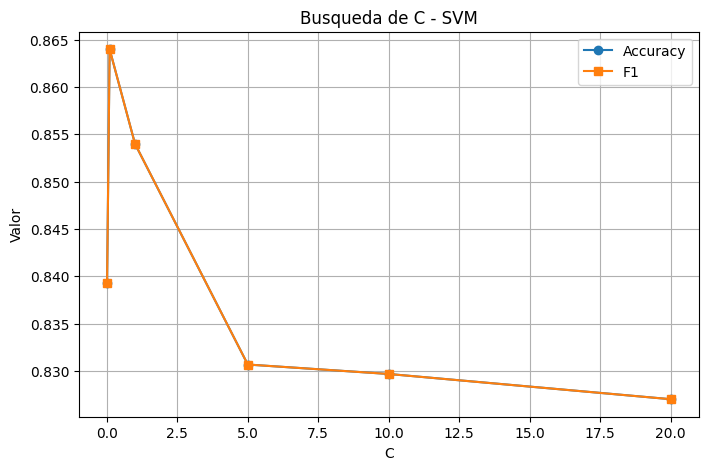


MEJOR NAIVE BAYES
Alpha       1.000000
Accuracy    0.849333
F1          0.849333
Name: 3, dtype: float64

MEJOR SVM
C           0.100000
Accuracy    0.864000
F1          0.863999
Name: 1, dtype: float64


In [17]:
# =====================================
# BUSQUEDA DE HIPERPARAMETROS
# =====================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------
# Naive Bayes
# -------------------------------------

valores_alpha = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

resultados_nb = []

for alpha in valores_alpha:

    modelo = MultinomialNB(
        alpha=alpha
    )

    modelo.fit(
        X_entrenamiento_tfidf,
        y_entrenamiento
    )

    predicciones = modelo.predict(
        X_prueba_tfidf
    )

    accuracy = accuracy_score(
        y_prueba,
        predicciones
    )

    f1 = f1_score(
        y_prueba,
        predicciones,
        average="weighted"
    )

    resultados_nb.append([
        alpha,
        accuracy,
        f1
    ])

tabla_nb = pd.DataFrame(
    resultados_nb,
    columns=[
        "Alpha",
        "Accuracy",
        "F1"
    ]
)

print("RESULTADOS NAIVE BAYES")
display(tabla_nb)

# -------------------------------------
# Grafica Naive Bayes
# -------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    tabla_nb["Alpha"],
    tabla_nb["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    tabla_nb["Alpha"],
    tabla_nb["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("Alpha")
plt.ylabel("Valor")
plt.title("Busqueda de Alpha - Naive Bayes")

plt.legend()
plt.grid()

plt.show()

# -------------------------------------
# SVM
# -------------------------------------

valores_c = [0.01, 0.1, 1, 5, 10, 20]

resultados_svm = []

for c in valores_c:

    modelo = LinearSVC(
        C=c,
        random_state=42
    )

    modelo.fit(
        X_entrenamiento_tfidf,
        y_entrenamiento
    )

    predicciones = modelo.predict(
        X_prueba_tfidf
    )

    accuracy = accuracy_score(
        y_prueba,
        predicciones
    )

    f1 = f1_score(
        y_prueba,
        predicciones,
        average="weighted"
    )

    resultados_svm.append([
        c,
        accuracy,
        f1
    ])

tabla_svm = pd.DataFrame(
    resultados_svm,
    columns=[
        "C",
        "Accuracy",
        "F1"
    ]
)

print("RESULTADOS SVM")
display(tabla_svm)

# -------------------------------------
# Grafica SVM
# -------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    tabla_svm["C"],
    tabla_svm["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    tabla_svm["C"],
    tabla_svm["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("C")
plt.ylabel("Valor")
plt.title("Busqueda de C - SVM")

plt.legend()
plt.grid()

plt.show()

# -------------------------------------
# Mejor parametro NB
# -------------------------------------

mejor_nb = tabla_nb.loc[
    tabla_nb["F1"].idxmax()
]

print("\nMEJOR NAIVE BAYES")
print(mejor_nb)

# -------------------------------------
# Mejor parametro SVM
# -------------------------------------

mejor_svm = tabla_svm.loc[
    tabla_svm["F1"].idxmax()
]

print("\nMEJOR SVM")
print(mejor_svm)

BLOQUE 2. Curva ROC y AUC

Este bloque genera:

ROC Naive Bayes
ROC SVM
AUC de ambos modelos

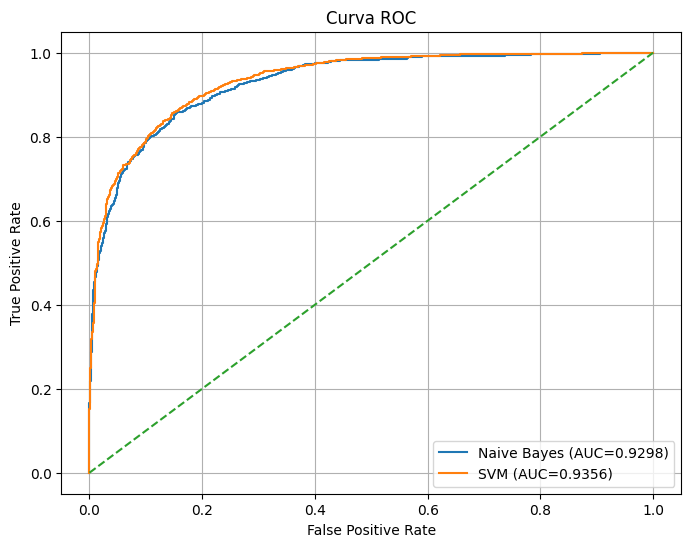

AUC NAIVE BAYES
0.9298

AUC SVM
0.9356


In [18]:
# =====================================
# CURVAS ROC Y AUC
# =====================================

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import matplotlib.pyplot as plt

# -------------------------------------
# Preparar etiquetas
# 1 = negativo
# 2 = positivo
# -------------------------------------

y_prueba_binaria = (
    y_prueba == 2
).astype(int)

# -------------------------------------
# Naive Bayes
# -------------------------------------

probabilidades_nb = modelo_naive_bayes.predict_proba(
    X_prueba_tfidf
)

prob_positiva_nb = probabilidades_nb[:, 1]

fpr_nb, tpr_nb, _ = roc_curve(
    y_prueba_binaria,
    prob_positiva_nb
)

auc_nb = auc(
    fpr_nb,
    tpr_nb
)

# -------------------------------------
# SVM
# -------------------------------------

puntajes_svm = modelo_svm.decision_function(
    X_prueba_tfidf
)

fpr_svm, tpr_svm, _ = roc_curve(
    y_prueba_binaria,
    puntajes_svm
)

auc_svm = auc(
    fpr_svm,
    tpr_svm
)

# -------------------------------------
# Graficar
# -------------------------------------

plt.figure(figsize=(8,6))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes (AUC={auc_nb:.4f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC={auc_svm:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.grid()

plt.show()

# -------------------------------------
# Mostrar AUC
# -------------------------------------

print("AUC NAIVE BAYES")
print(round(auc_nb,4))

print()

print("AUC SVM")
print(round(auc_svm,4))

MATRIZ DE CONFUSION - NAIVE BAYES
[[1275  225]
 [ 227 1273]]


<Figure size 600x600 with 0 Axes>

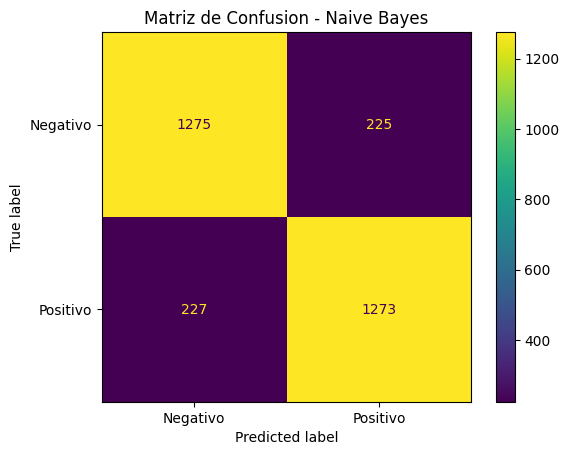


MATRIZ DE CONFUSION - SVM
[[1292  208]
 [ 200 1300]]


<Figure size 600x600 with 0 Axes>

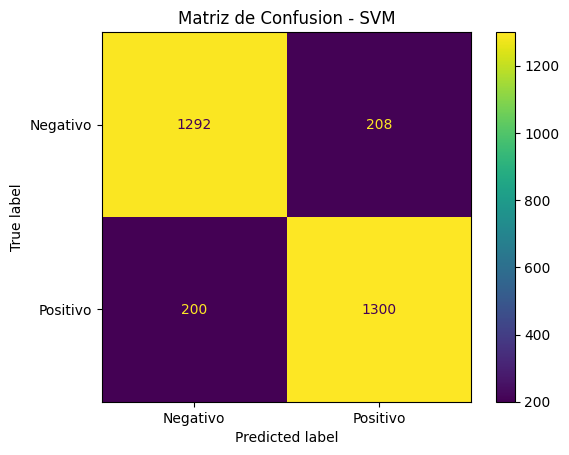

In [19]:
# =====================================
# MATRICES DE CONFUSION FINALES
# =====================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# -------------------------------------
# Mejor Naive Bayes
# -------------------------------------

modelo_nb_final = MultinomialNB(
    alpha=1.0
)

modelo_nb_final.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

predicciones_nb_final = modelo_nb_final.predict(
    X_prueba_tfidf
)

# -------------------------------------
# Mejor SVM
# -------------------------------------

modelo_svm_final = LinearSVC(
    C=0.1,
    random_state=42
)

modelo_svm_final.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

predicciones_svm_final = modelo_svm_final.predict(
    X_prueba_tfidf
)

# -------------------------------------
# Matriz Naive Bayes
# -------------------------------------

matriz_nb = confusion_matrix(
    y_prueba,
    predicciones_nb_final
)

print("MATRIZ DE CONFUSION - NAIVE BAYES")
print(matriz_nb)

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_nb,
    display_labels=[
        "Negativo",
        "Positivo"
    ]
).plot()

plt.title(
    "Matriz de Confusion - Naive Bayes"
)

plt.show()

# -------------------------------------
# Matriz SVM
# -------------------------------------

matriz_svm = confusion_matrix(
    y_prueba,
    predicciones_svm_final
)

print("\nMATRIZ DE CONFUSION - SVM")
print(matriz_svm)

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_svm,
    display_labels=[
        "Negativo",
        "Positivo"
    ]
).plot()

plt.title(
    "Matriz de Confusion - SVM"
)

plt.show()

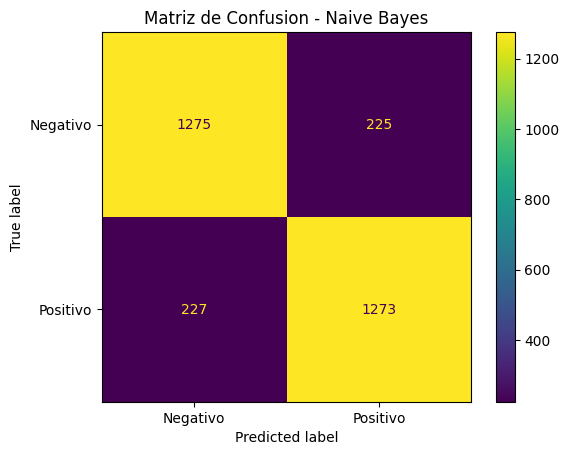

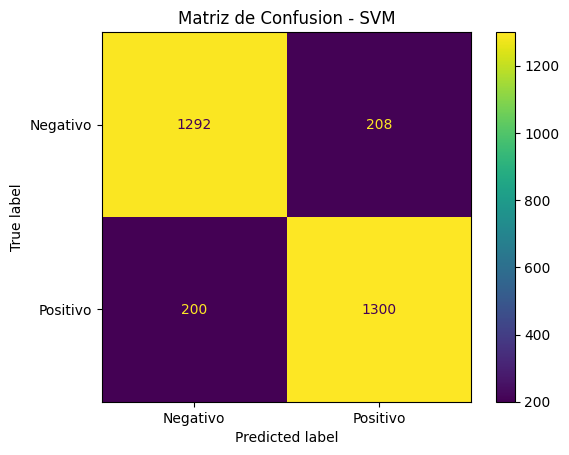

Imagenes guardadas.


In [20]:
# =====================================
# GUARDAR MATRIZ NAIVE BAYES
# =====================================

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=matriz_nb,
    display_labels=[
        "Negativo",
        "Positivo"
    ]
)

disp_nb.plot()

plt.title(
    "Matriz de Confusion - Naive Bayes"
)

plt.savefig(
    os.path.join(
        ruta_proyecto,
        "matriz_confusion_naive_bayes.png"
    ),
    bbox_inches="tight"
)

plt.show()

# =====================================
# GUARDAR MATRIZ SVM
# =====================================

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=matriz_svm,
    display_labels=[
        "Negativo",
        "Positivo"
    ]
)

disp_svm.plot()

plt.title(
    "Matriz de Confusion - SVM"
)

plt.savefig(
    os.path.join(
        ruta_proyecto,
        "matriz_confusion_svm.png"
    ),
    bbox_inches="tight"
)

plt.show()

print("Imagenes guardadas.")

Verificacion final de modelos guardados

In [21]:
# =====================================
# GUARDAR MODELOS FINALES
# =====================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import pickle
import os

# -------------------------------------
# Entrenar mejor Naive Bayes
# -------------------------------------

modelo_nb_final = MultinomialNB(
    alpha=1.0
)

modelo_nb_final.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

# -------------------------------------
# Entrenar mejor SVM
# -------------------------------------

modelo_svm_final = LinearSVC(
    C=0.1,
    random_state=42
)

modelo_svm_final.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

# -------------------------------------
# Rutas
# -------------------------------------

ruta_nb = os.path.join(
    ruta_proyecto,
    "modelo_naive_bayes.pkl"
)

ruta_svm = os.path.join(
    ruta_proyecto,
    "modelo_svm.pkl"
)

ruta_vectorizador = os.path.join(
    ruta_proyecto,
    "vectorizador_tfidf.pkl"
)

# -------------------------------------
# Guardar Naive Bayes
# -------------------------------------

with open(ruta_nb, "wb") as archivo:
    pickle.dump(
        modelo_nb_final,
        archivo
    )

# -------------------------------------
# Guardar SVM
# -------------------------------------

with open(ruta_svm, "wb") as archivo:
    pickle.dump(
        modelo_svm_final,
        archivo
    )

print("Modelos guardados correctamente.")

# =====================================
# VERIFICAR CARGA
# =====================================

with open(ruta_vectorizador, "rb") as archivo:
    vectorizador_cargado = pickle.load(
        archivo
    )

with open(ruta_nb, "rb") as archivo:
    modelo_nb_cargado = pickle.load(
        archivo
    )

with open(ruta_svm, "rb") as archivo:
    modelo_svm_cargado = pickle.load(
        archivo
    )

print("Modelos cargados correctamente.")

# =====================================
# PRUEBA RAPIDA
# =====================================

texto_prueba = [
    "excellent product works perfectly highly recommended"
]

texto_tfidf = vectorizador_cargado.transform(
    texto_prueba
)

pred_nb = modelo_nb_cargado.predict(
    texto_tfidf
)

pred_svm = modelo_svm_cargado.predict(
    texto_tfidf
)

print("\nPrediccion Naive Bayes:")
print(pred_nb[0])

print("\nPrediccion SVM:")
print(pred_svm[0])

print("\nVerificacion completada.")

Modelos guardados correctamente.
Modelos cargados correctamente.

Prediccion Naive Bayes:
2

Prediccion SVM:
2

Verificacion completada.


## Fase 10. Guardar métricas de modelos optimizados

In [22]:
import pandas as pd

# Subbloque 10.1 Crear tabla de métricas finales
# Crear tabla comparativa con los mejores resultados de hiperparámetros
tabla_metricas_final = pd.DataFrame({
    "Modelo": [
        "Naive Bayes (Optimizado)",
        "SVM (Optimizado)"
    ],
    "Alpha_or_C": [
        mejor_nb['Alpha'],
        mejor_svm['C']
    ],
    "Accuracy": [
        mejor_nb['Accuracy'],
        mejor_svm['Accuracy']
    ],
    "F1_Score": [
        mejor_nb['F1'],
        mejor_svm['F1']
    ]
})

# Redondear valores para presentación
tabla_metricas_final = tabla_metricas_final.round(4)

print("Tabla de Métricas de Modelos Optimizados:")
display(tabla_metricas_final)

# Subbloque 10.2 Guardar tabla comparativa final
# Definir ruta para el archivo CSV de métricas finales
ruta_metricas_final = os.path.join(
    ruta_proyecto,
    "metricas_modelos_optimizados.csv"
)

# Guardar tabla de métricas finales
tabla_metricas_final.to_csv(
    ruta_metricas_final,
    index=False
)

print("Tabla de métricas de modelos optimizados guardada en:")
print(ruta_metricas_final)

# Subbloque 10.3 Verificar archivo guardado
print("\nVerificación de archivo:")
print(os.path.exists(ruta_metricas_final))

Tabla de Métricas de Modelos Optimizados:


,Modelo,Alpha_or_C,Accuracy,F1_Score
0,Naive Bayes (Optimizado),1.0,0.8493,0.8493
1,SVM (Optimizado),0.1,0.8640,0.8640


Tabla de métricas de modelos optimizados guardada en:
/content/drive/MyDrive/Proyecto_Amazon_Reviews/metricas_modelos_optimizados.csv

Verificación de archivo:
True
